# **"FaceValue": The Biometric Compression Challenge**

### **The Scenario**

You are a lead engineer at **"FaceValue,"** a security startup. Your team needs to store thousands of high-resolution employee face scans on low-power hardware. Storing raw pixels is too expensive. You must use **Principal Component Analysis (PCA)** to find the "Eigen-faces"—the fundamental patterns that make up a human face—and use them to compress the images.



### **Part 1: Conceptual Stress-Tests**



>**How to approach these questions:**
>* **Q1:** Think about the definition of the 1st Principal Component. If variance is identical in all directions, can the math "choose" a winner?
>
>
> * **Q2:** PCA is sensitive to the *magnitude* of numbers. Consider what happens if one feature has a range of 10,000 and another has a range of 10.



**Question 1: The "Spherical" Data Problem**
Suppose your dataset is a perfect 2D circle of points centered at $(0,0)$. Every direction from the center has equal variance. If you calculate the 1st Principal Component ($v_1$):

**A)** It will point toward the densest cluster of points.

**B)** It will return an error because the covariance matrix  is not invertible.

**C)** The direction of $v_1$ is mathematically arbitrary (or determined by tiny noise), because no single direction captures "maximum" variance.

**D)** It will always default to the X-axis.



Answer: C) The direction of $v_1$ is mathematically arbitrary (or determined by tiny noise), because no single direction captures "maximum" variance.

Explanation: The 1st Principal Component ($v_1$) is defined as the direction of maximum variance. In a perfectly spherical distribution (like a 2D circle), the variance is identical in all directions. Therefore, there is no unique vector that maximizes variance, making the mathematical choice arbitrary or dependent on negligible numerical noise.


**Question 2: The Scaling Trap**
You are analyzing house data with two features: `Price` (in millions, range 0.1–5) and `SqFt` (range 500–5000). You forget to perform **Feature Normalization**.

**A)** PCA will still find the true underlying relationship accurately.

**B)** The 1st Principal Component will be almost entirely aligned with `SqFt` simply because the numerical values have higher variance.

**C)** The eigenvalues will automatically adjust to compensate for the scale difference.

**D)** The reconstruction error will become zero.



Answer: **B)** The 1st Principal Component will be almost entirely aligned with `SqFt` simply because the numerical values have higher variance.

Explanation: PCA is highly sensitive to the scale/magnitude of features. Features with larger numerical ranges  will naturally have much higher mathematical variance than features with smaller ranges . without normalization PCA will prioritize the high magnitude feature as the primary source of variance regardless of its actual importance.


### **Part 2: The Geometry of Information**





> **How to approach Q3:** Use the **Eigenvalue Spectrum** formula. The "information" preserved is the sum of the eigenvalues you keep divided by the sum of all possible eigenvalues.




**Question 3: The 95% Variance Rule**
Your total sum of eigenvalues $\sum_{i=1}^{D} \lambda_i$ is **100**. Your first three eigenvalues are $ \lambda_1 =65, \lambda_2=25$ and $\lambda_3=7$.
If your goal is to preserve **at least 95%** of the data's variance, can you compress this data into just **2 dimensions**? Show your calculation based on the formula from **Slide 12**.



![WhatsApp Image 2026-01-27 at 22.23.34.jpeg](<attachment:WhatsApp Image 2026-01-27 at 22.23.34.jpeg>)
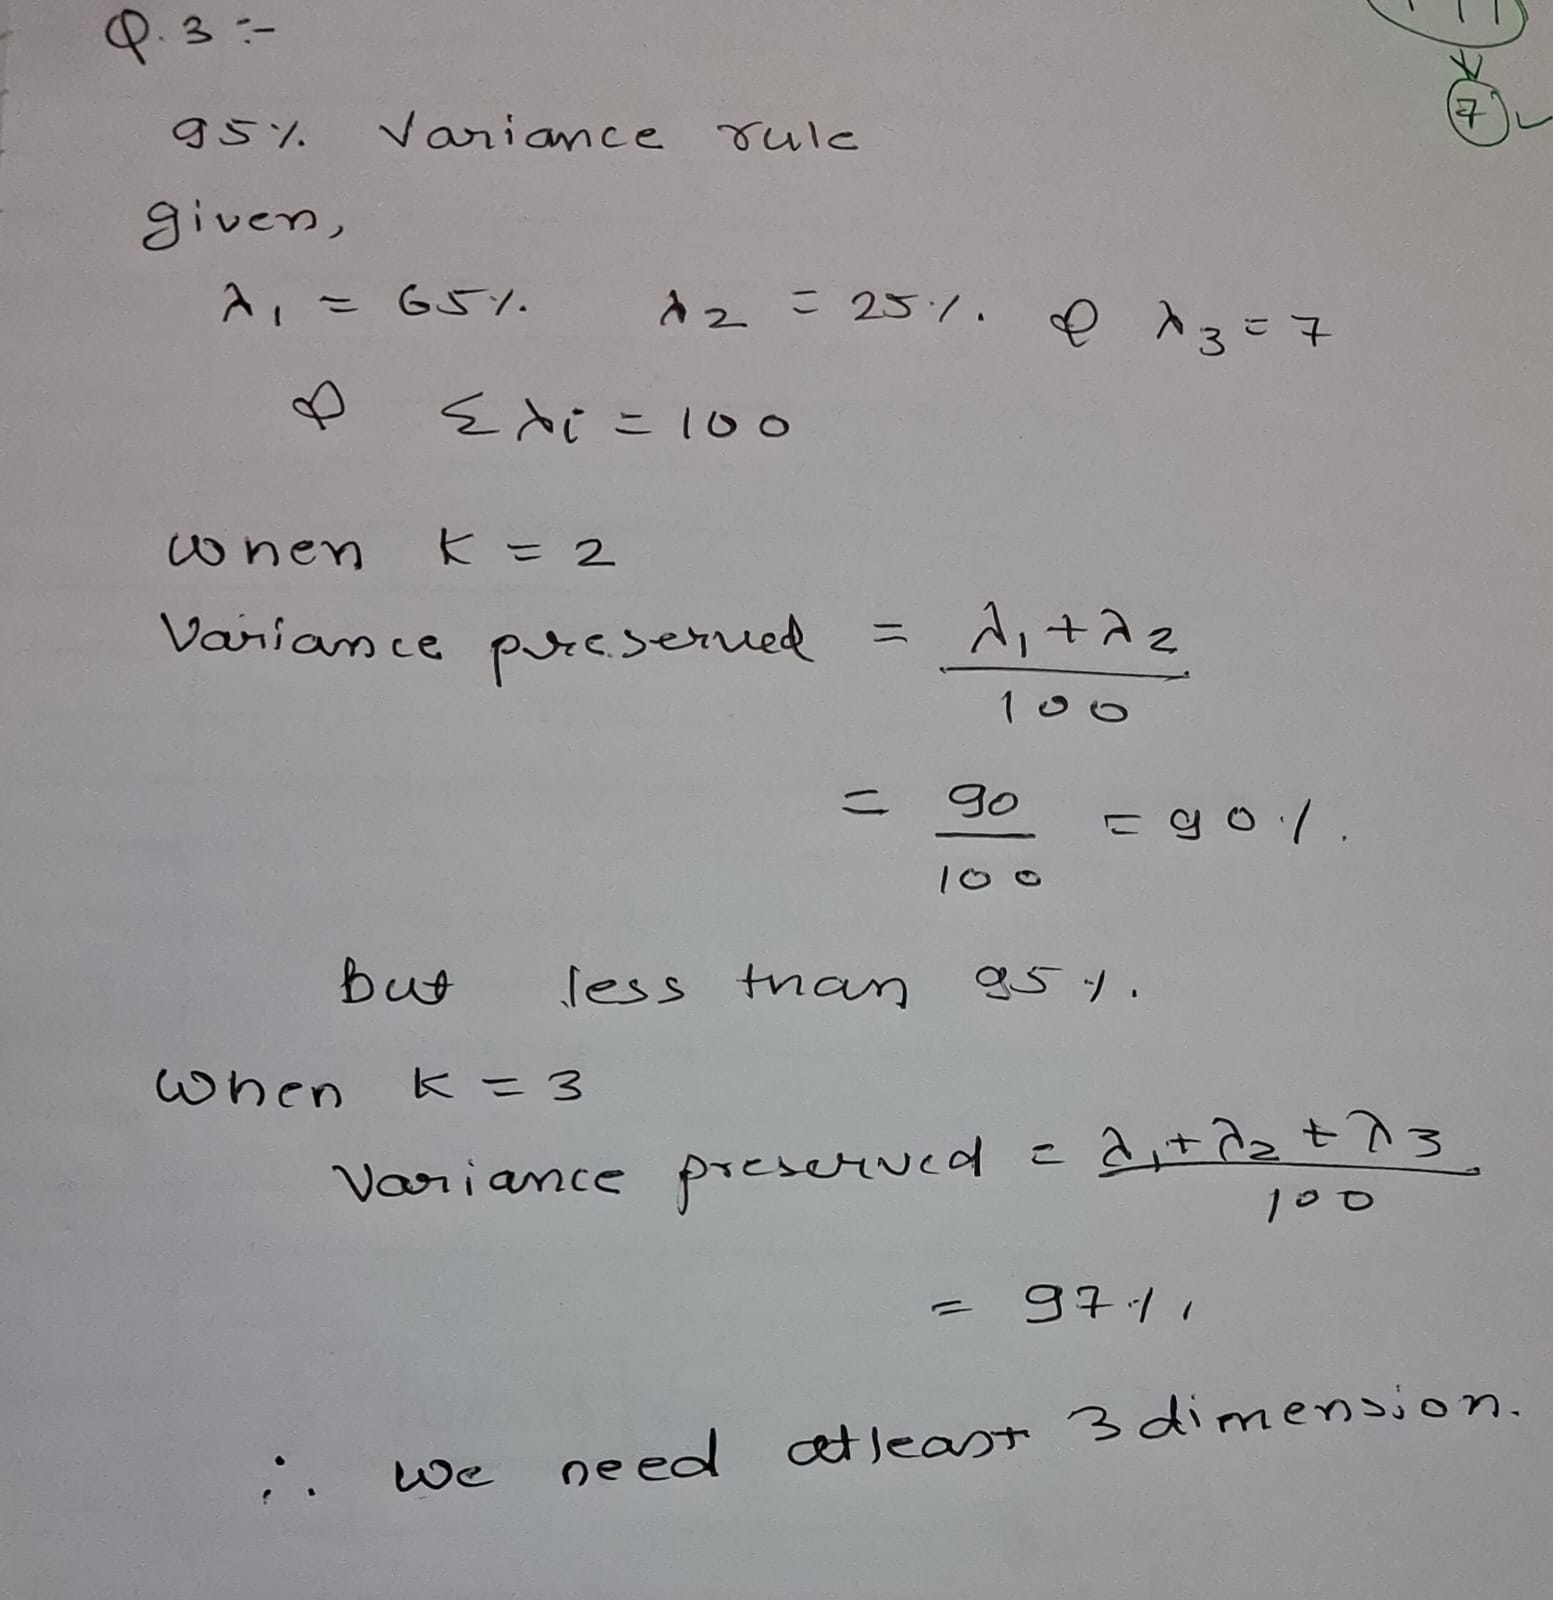

> **How to approach Q4:** Consider the size of the covariance matrix. If you have 200 images of 10,000 pixels, is it better to find the eigenvectors of a  matrix or a  matrix?
>
>

**Question 4: The Large , Small  Problem**
On **Slide 18**, we discuss a case with 200 images (N) of 100x100 pixels (D=10000).
The standard covariance matrix would be 10000x10000 .

1. What is the **maximum possible rank** of this matrix? (Hint: It cannot exceed N).


2. If the rank is only 200, why is it computationally "expensive" to solve the 10000x10000  system directly?


Answer:
1. Maximum possible rank: The maximum rank is N - 1 (where $N$ is the number of images). In this case with 200 images the maximum rank is 199 (often simplified to N, which is 200).

2. Computational Expense: Even if the rank is small, solving a 10000 x 10000 system directly is expensive because the covariance matrix has $D^2$ elements ($10^8$ entries), requiring massive memory and $O(D^3)$ computations to find all eigenvectors. It is more efficient to find the eigenvectors of the $N \times N$ ($200 \times 200$) matrix and then project them back to $D$ space.


## **Part 3: Coding Challenge — Eigen-faces with Scikit-Learn**



In this section, you will load a real dataset of faces, compute the PCA components, and observe how the image quality changes as we increase the number of dimensions (k).


**Helper functions are in the pca_utils.py file. Upload that to the session runtime by clicking on the 'Files' icon on the left pane.**


**You are required to:**

**A) Write your observations in Section 5**

**B) Implement PCA using scikit-learn. Fill in the two missing lines**

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import sys
import os

from pca_utils import *

### SECTION 1: Loading Eigenfaces Dataset

Number of samples: 1288
Number of features (pixels): 1850
Image dimensions: 50x37
Number of classes (people): 7
Classes: ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


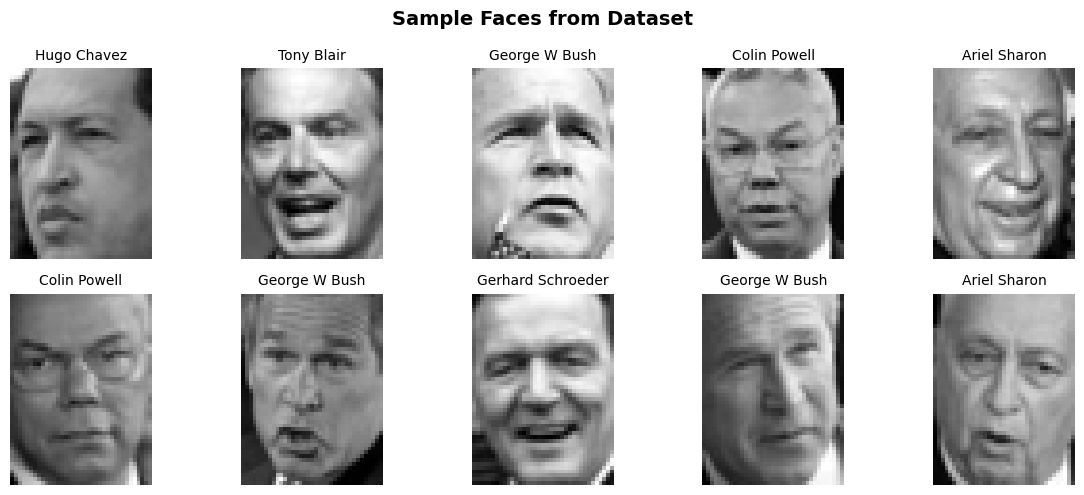

In [2]:
faces, X, y, target_names, h, w = load_eigenfaces_data()
print_dataset_info(X, target_names, h, w)


plot_sample_faces(faces, y, target_names)




 ### SECTION 2: PCA from Scratch

In [3]:

# Step 1: Center the data
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean
print(f"✓ Data centered. Mean shape: {X_mean.shape}")

# Step 2: Compute covariance matrix
cov_matrix = np.cov(X_centered.T)
print(f"✓ Covariance matrix shape: {cov_matrix.shape}")

# Step 3: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(f"✓ Computed {len(eigenvalues)} eigenvalues and eigenvectors")

# Step 4: Sort by eigenvalues (descending order)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Keep only real parts
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

print(f"✓ Top 5 eigenvalues: {eigenvalues[:5]}")

✓ Data centered. Mean shape: (1850,)
✓ Covariance matrix shape: (1850, 1850)
✓ Computed 1850 eigenvalues and eigenvectors
✓ Top 5 eigenvalues: [8.41416639 5.70775293 2.83065828 2.33295885 1.98951978]


### SECTION 3: Visualizing Eigenfaces

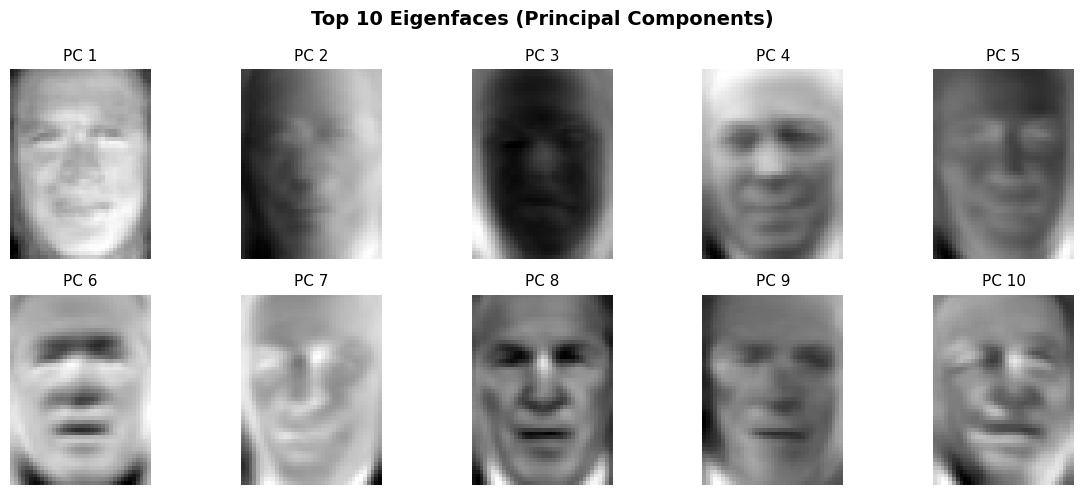

In [4]:
plot_eigenfaces(eigenvectors, h, w)

### SECTION 4: Understanding Variance Explained
Observe how much information does each component capture.

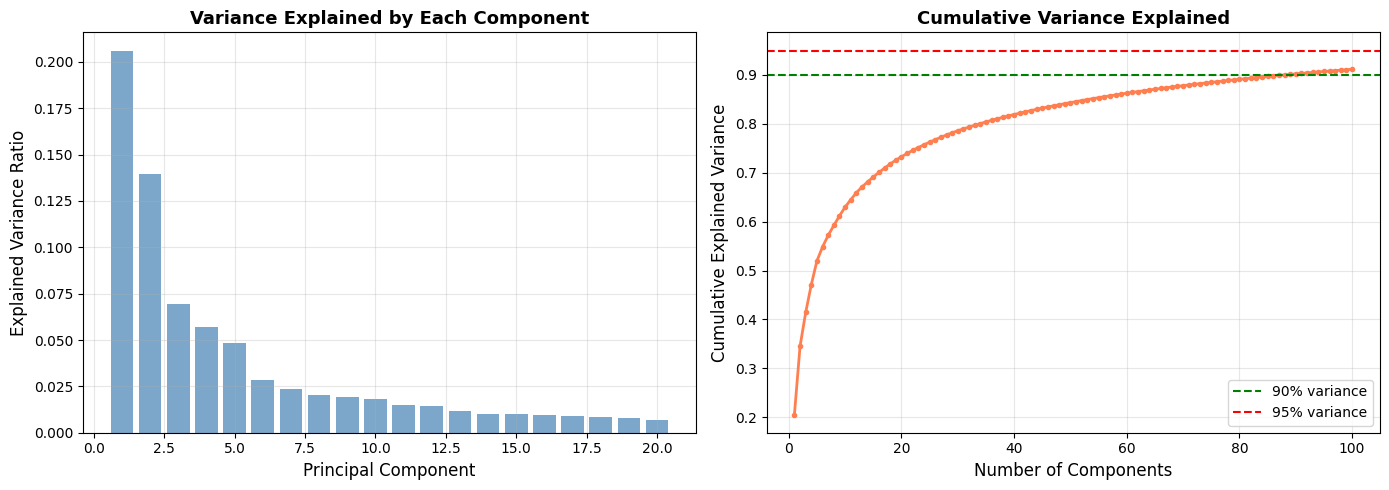


 Components needed for 90% variance: 88
 Components needed for 95% variance: 167


In [5]:
cumulative_variance = plot_variance_explained(eigenvalues)

# Find components needed for different variance thresholds
n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\n Components needed for 90% variance: {n_comp_90}")
print(f" Components needed for 95% variance: {n_comp_95}")

### SECTION 5: Face Reconstruction
See how well we can reconstruct a face using different numbers of components. **Write your observations.**


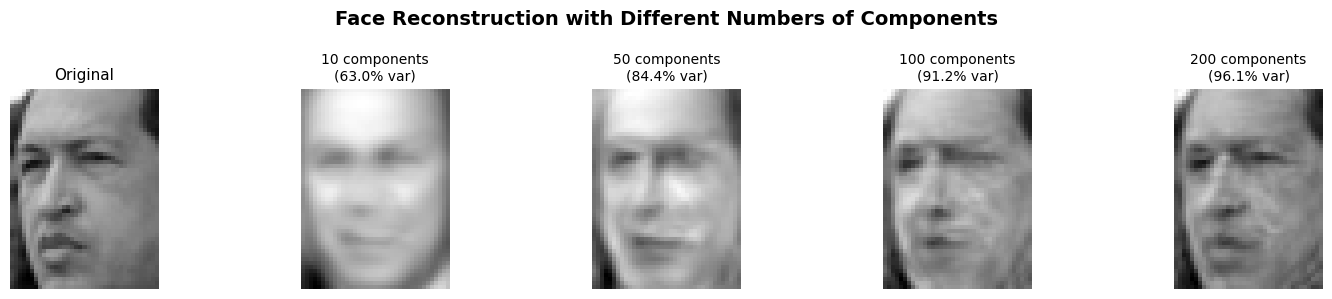

In [6]:
plot_reconstruction_comparison(X, X_centered, X_mean, eigenvectors,
                              cumulative_variance, h, w, sample_idx=0)

Observations:

1. As the number of components (k) increases the quality of the reconstructed face improves significantly. with very few components the image appears blurry and lacks detail but as k approaches the total number of components the reconstruction becomes nearly identical to the original image.

2. By reducing the dimensionality from 1,850 pixels down to just 200 principal components we achieved roughly 12x compression. Despite this massive reduction in data size we retained 96.1% of the total variance which is more than enough for reliable facial recognition.

3. looking at the reconstrction plots using only 10 components results in a "ghostly" average face where only the lighting and head shape are visible. However by 200 components the reconstruction is nearly indistinguishable from the original capturing individual features like eyes mouth shape and even some texture.


### SECTION 6: Using Scikit-learn PCA
Implement Scikit-learn PCA on data stored in X. Then, run the code, which will help verify our pca implementation from scratch.

Original shape: (1288, 1850)
Transformed shape: (1288, 150)
Variance explained: 94.27%

✓ Our implementation matches sklearn: True


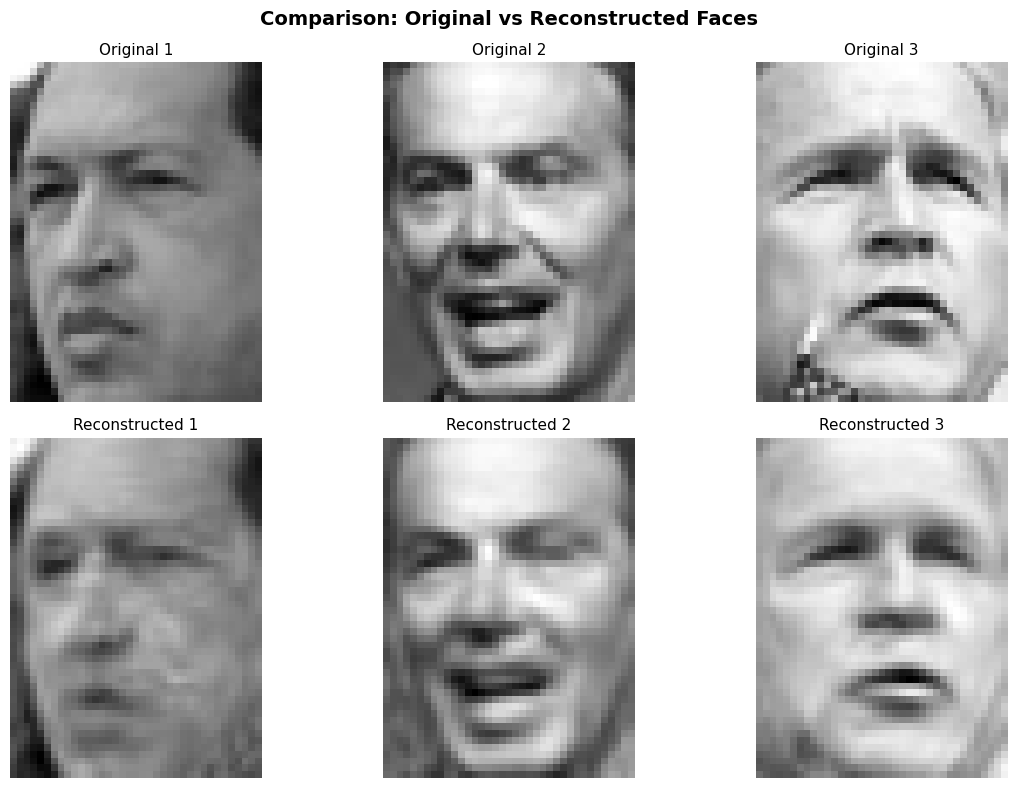

In [7]:
n_components = 150
#Fill in here ----------------------------------

pca = PCA(n_components=n_components, whiten=True)
X_pca = pca.fit_transform(X)

#----------------------------------
print(f"Original shape: {X.shape}")
print(f"Transformed shape: {X_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Verify our implementation
matches = np.allclose(eigenvalues[:5], pca.explained_variance_[:5], rtol=1e-3)
print(f"\n✓ Our implementation matches sklearn: {matches}")

# Reconstruct using sklearn
X_reconstructed = pca.inverse_transform(X_pca)

# Visualize
plot_sklearn_comparison(X, X_reconstructed, h, w, n_samples=3)
